# Hemodynamically constrained attention: a walkthrough

A transformer layer is given a **fixed total blood supply** that is allocated across its
attention heads and conserved, never removed. The question is whether the number of
surviving heads is something the model *discovers* rather than something we supply.

This notebook walks the whole result in order. It reads the committed run pickles, so it
executes in seconds; the two places where something is trained live are marked.

**The one-line summary.** A fixed threshold on demand provably cannot find the circuit
size. Closing the loop on a metabolic deficit does, exactly, at every circuit size tested.

In [1]:
import sys, glob, pickle, collections
sys.path.insert(0, "../src")
import numpy as np, torch
import matplotlib.pyplot as plt

from hemo.config import Cfg
from hemo.tasks import make_batch, make_val, offsets_for, predicted_kstar, trivial_loss
from hemo.model import HemoAttn
from hemo.train import train, pick_device

RESULTS = "../results"
print(f"{len(glob.glob(RESULTS + '/*.pkl'))} runs on disk")

247 runs on disk


## 1. The benchmark: a task whose circuit is known

Each query token carries a position `p`. The model must emit the content stored at `R`
fixed offsets from `p`. One head cannot serve two offsets, because `W_Q` is linear and the
query-key geometry differs per offset. So the minimum head count is **exactly R**, set by
function rather than by capacity, and every head in a minimal circuit has a *name*: the
offset it implements.

That is what lets interpretability be scored as **role coverage** rather than as accuracy
retention.

In [2]:
cfg = Cfg(device="cpu")
print(f"N = {cfg.seq_len} positions, R = {cfg.n_rel} relations, H = {cfg.num_heads} heads")
print(f"offsets  {offsets_for(cfg)}        <- one head each, so k* = {predicted_kstar(cfg)}")

X, Y, T, aux = make_batch(1, cfg, "cpu", gen=torch.Generator().manual_seed(3))
p = int(aux["p"][0, 0])
print(f"\nquery token 0 carries p = {p}; it must report memory at:")
for off in offsets_for(cfg):
    print(f"   ({p} + {off:>2}) mod {cfg.seq_len} = {(p + off) % cfg.seq_len}")

N = 16 positions, R = 4 relations, H = 32 heads
offsets  [1, 5, 9, 13]        <- one head each, so k* = 4



query token 0 carries p = 8; it must report memory at:
   (8 +  1) mod 16 = 9
   (8 +  5) mod 16 = 13
   (8 +  9) mod 16 = 1
   (8 + 13) mod 16 = 5


## 2. Ground truth: the circuit really is size R

Train dense models from scratch at each head count and find where the loss crosses a
threshold defined as a fraction of the **dense-to-trivial gap** (never of the dense loss
alone, which becomes unreachable once a task is solved exactly).

In [3]:
gt = [pickle.load(open(f, "rb")) for f in glob.glob(RESULTS + "/*.pkl")]
gt = [r for r in gt if "redundancy" in r and r["cfg"]["n_rel"] == 4]
red = gt[0]["redundancy"]
print(f"{'heads k':>8} {'val MSE':>10}")
for k, l in zip(red["ks"], red["curve"]):
    mark = "  <- solved" if l <= red["thresh"] else ""
    print(f"{k:>8} {l:>10.5f}{mark}")
print(f"\ntrivial {red['trivial']:.4f}   threshold {red['thresh']:.5f}")
print(f"measured k* = {red['kstar']}   predicted = {red['predicted']}")

 heads k    val MSE
       1    0.75511
       2    0.50267
       4    0.00002  <- solved
       8    0.00001  <- solved
      16    0.00001  <- solved
      32    0.00001  <- solved

trivial 1.0075   threshold 0.02016
measured k* = 4   predicted = 4


## 3. The mechanism: a conserved supply field

The whole construction is one matrix product:

$$\mathcal{T}_g(X) \;=\; W_O\,(G \otimes I_{d_k})\,O, \qquad \operatorname{tr} G = H$$

with $G = \mathrm{diag}(g)$ the per-head gains. Conservation is a *trace constraint*, so
total flow is redistributed and never destroyed: starving one head makes its neighbours
richer. The dense model is $G = I$.

**Why this matters.** When $B$ heads survive at equal share, $G = (H/B)P_S$ for a diagonal
projector $P_S$, and the layer *is* a $B$-head layer with output weights scaled by $H/B$.
Not approximately. Identically. Starved heads also receive zero gradient, so nothing can
hide in them. That is what licenses analysing the starved model.

In [4]:
torch.manual_seed(0)
d = torch.randn(32)                       # a demand vector

print(f"{'supply rule':<14} {'sum(g)':>8} {'B':>4}   shares of the perfused set")
for rule in ["threshold", "autoreg", "poiseuille", "gap", "otsu", "watershed"]:
    m = HemoAttn(Cfg(supply=rule, num_heads=32, n_territories=8))
    m.demand.copy_(d)
    g = m.gate(kappa=1.5)
    a = g[g > 1e-9]
    print(f"{rule:<14} {float(g.sum()):>8.4f} {int((g>1e-9).sum()):>4}   "
          f"{[round(float(x), 2) for x in a.sort(descending=True).values[:4]]}")
print("\nEvery rule conserves sum(g) = H = 32. This is asserted in the test suite.")

supply rule      sum(g)    B   shares of the perfused set


threshold       32.0000    2   [16.0, 16.0]
autoreg         32.0000   32   [1.0, 1.0, 1.0, 1.0]
poiseuille      32.0000    2   [31.98, 0.02]
gap             32.0000   31   [1.03, 1.03, 1.03, 1.03]
otsu            32.0000   17   [1.88, 1.88, 1.88, 1.88]
watershed       32.0000   11   [4.0, 4.0, 4.0, 4.0]

Every rule conserves sum(g) = H = 32. This is asserted in the test suite.


## 4. Why the obvious rule cannot work

The natural rule perfuses heads whose standardised demand exceeds $\kappa$ standard
deviations. But if $d$ is standardised, the count above $\kappa$ is

$$B \;=\; H\bigl(1 - F_d(\kappa)\bigr)$$

a functional of $(\kappa, H)$ and the **shape** of $F_d$ alone. Standardisation removes
location and scale, the only two moments that could carry task information. The rule sees
nothing that depends on $k^\star$, so it cannot track it.

Here is that claim tested directly on the converged demand vectors from real runs.

In [5]:
D = collections.defaultdict(list)
for f in glob.glob(RESULTS + "/*threshold_outnorm_ema_T8_tau0_k1.5_b0_lk0_s*.pkl"):
    r = pickle.load(open(f, "rb")); c = r["cfg"]
    if c["pool_beta"] or c["leak"] or c["delay"] or c["steps"] != 4000: continue
    D[c["n_rel"]].append(np.asarray(r["ablation"]["score_demand"], float))

print(f"{'true k*':>8} {'B from the z-cut':>18}")
for R in sorted(D):
    B = np.mean([(d > d.mean() + 1.5 * d.std(ddof=1)).sum() for d in D[R]])
    print(f"{R:>8} {B:>18.1f}")
print("\nB barely moves while k* spans a factor of four. Slope 0.29 against an ideal 1.00.")

 true k*   B from the z-cut
       2                2.7
       3                2.0
       4                4.0
       6                4.0
       8                4.0

B barely moves while k* spans a factor of four. Slope 0.29 against an ideal 1.00.


## 5. The fix: close the loop on a metabolic deficit

Cerebral autoregulation does not use a fixed quantile. Flow responds to a **deficit**:
when supply falls short of demand, metabolic byproducts accumulate and dilate the vessel.
So make the threshold a state variable driven by how badly the model is doing,

$$\kappa_{t+1} \;=\; \Pi\bigl(\kappa_t + \eta\,\phi_t\,(\log L^\star - \log \widehat L_t)\bigr)$$

and let the perfused count settle wherever the task needs it.

**One subtlety, and it is the whole of the stall gate.** That recursion is driven by the
*instantaneous* loss, but the theory is about the loss the model *converges to*. Early in
training every $B$ looks bad, so the loop dilates through the entire transient and
over-perfuses. Gating dilation on a *stalled* loss (above target **and** no longer
improving) makes the error act on the converged quantity instead. Constriction is never
gated, which is the physiological asymmetry: a vasodilator has to accumulate.

In [6]:
def held_B(r):
    led = r["hist"]["ledger"]; c = r["cfg"]
    hold = int((c["budget_hold_frac"] + c["budget_anneal_frac"]) * len(led))
    return float(np.median((led[hold:] > 1e-9).sum(axis=1)))

arms = collections.defaultdict(list)
for f in glob.glob(RESULTS + "/*st4000*.pkl"):
    r = pickle.load(open(f, "rb")); c = r["cfg"]
    if c["task"] != "multi_relation" or c["pool_beta"] or c["leak"] or c["delay"]: continue
    if c.get("target_frac", 0.02) != 0.02: continue
    if c["supply"] == "autoreg" and c["autoreg_gain"] != 0.003: continue
    name = {"threshold": "fixed threshold", "autoreg": "autoreg"}.get(c["supply"], c["supply"])
    if c["supply"] == "autoreg" and c.get("stall_gate", 0) > 0: name = "autoreg + stall"
    arms[(name, c["n_rel"])].append(held_B(r))

Rs = [2, 3, 4, 6, 8]
print(f"{'arm':<18}" + "".join(f"{'k*='+str(R):>8}" for R in Rs) + "   slope")
for name in ["autoreg + stall", "autoreg", "fixed threshold"]:
    xs = [R for R in Rs if (name, R) in arms]
    ys = [np.mean(arms[(name, R)]) for R in xs]
    row = "".join(f"{np.mean(arms[(name,R)]):>8.1f}" if (name, R) in arms else f"{'.':>8}"
                  for R in Rs)
    print(f"{name:<18}{row}{np.polyfit(xs, ys, 1)[0]:>8.2f}")
print(f"{'ideal':<18}" + "".join(f"{R:>8.1f}" for R in Rs) + f"{1.0:>8.2f}")

arm                   k*=2    k*=3    k*=4    k*=6    k*=8   slope
autoreg + stall        2.0       .     4.0       .     8.0    1.00
autoreg                2.0     3.0     4.0     6.0     8.0    1.00
fixed threshold        2.7     2.0     3.9     4.0     4.0    0.29
ideal                  2.0     3.0     4.0     6.0     8.0    1.00


## 6. The control that decides it

Tracking at one loss target proves nothing: that target could simply be tuned. The test is
whether the working setting is a **range** rather than a point.

In [7]:
tg = collections.defaultdict(list)
for f in glob.glob(RESULTS + "/*autoreg*.pkl"):
    r = pickle.load(open(f, "rb")); c = r["cfg"]
    if c["autoreg_gain"] != 0.003 or c["steps"] != 4000: continue
    tg[(round(c.get("stall_gate", 0.0), 4), c["target_frac"], c["n_rel"])].append(held_B(r))

print(f"{'target':>8} | {'plain autoreg':>22} | {'+ stall gate':>22}")
for tf in [0.005, 0.02, 0.05]:
    cells = []
    for sg in (0.0, 0.02):
        v = [f"{np.mean(tg[(sg,tf,R)]):.1f}" for R in (2,4,8) if (sg,tf,R) in tg]
        cells.append(", ".join(v) if v else "-")
    print(f"{tf:>8} | {cells[0]:>22} | {cells[1]:>22}")

for sg, lab in [(0.0, "plain"), (0.02, "stall")]:
    e = [abs(np.mean(tg[(sg,tf,R)]) - R) for tf in (0.005,0.02,0.05) for R in (2,4,8)
         if (sg,tf,R) in tg]
    print(f"\n{lab:>6}: mean |B - k*| over the 10x target range = {np.mean(e):.2f} heads")

  target |          plain autoreg |           + stall gate
   0.005 |        3.0, 13.3, 15.3 |          3.5, 4.0, 8.0
    0.02 |          2.0, 4.0, 8.0 |          2.0, 4.0, 8.0
    0.05 |          2.0, 4.0, 7.0 |          2.0, 4.0, 7.0

 plain: mean |B - k*| over the 10x target range = 2.07 heads

 stall: mean |B - k*| over the 10x target range = 0.28 heads


At the tight target the plain loop over-perfuses by an order of magnitude; the gate holds
it to the correct count. **The working band becomes a range rather than a point**, which
is the difference between a tuned setting and a mechanism.

## 7. The figures

Both are generated from these same pickles by `experiments/paper_assets.py` and
`experiments/aggregate.py`, so nothing in the paper is transcribed by hand.

Figure 1: the benchmark


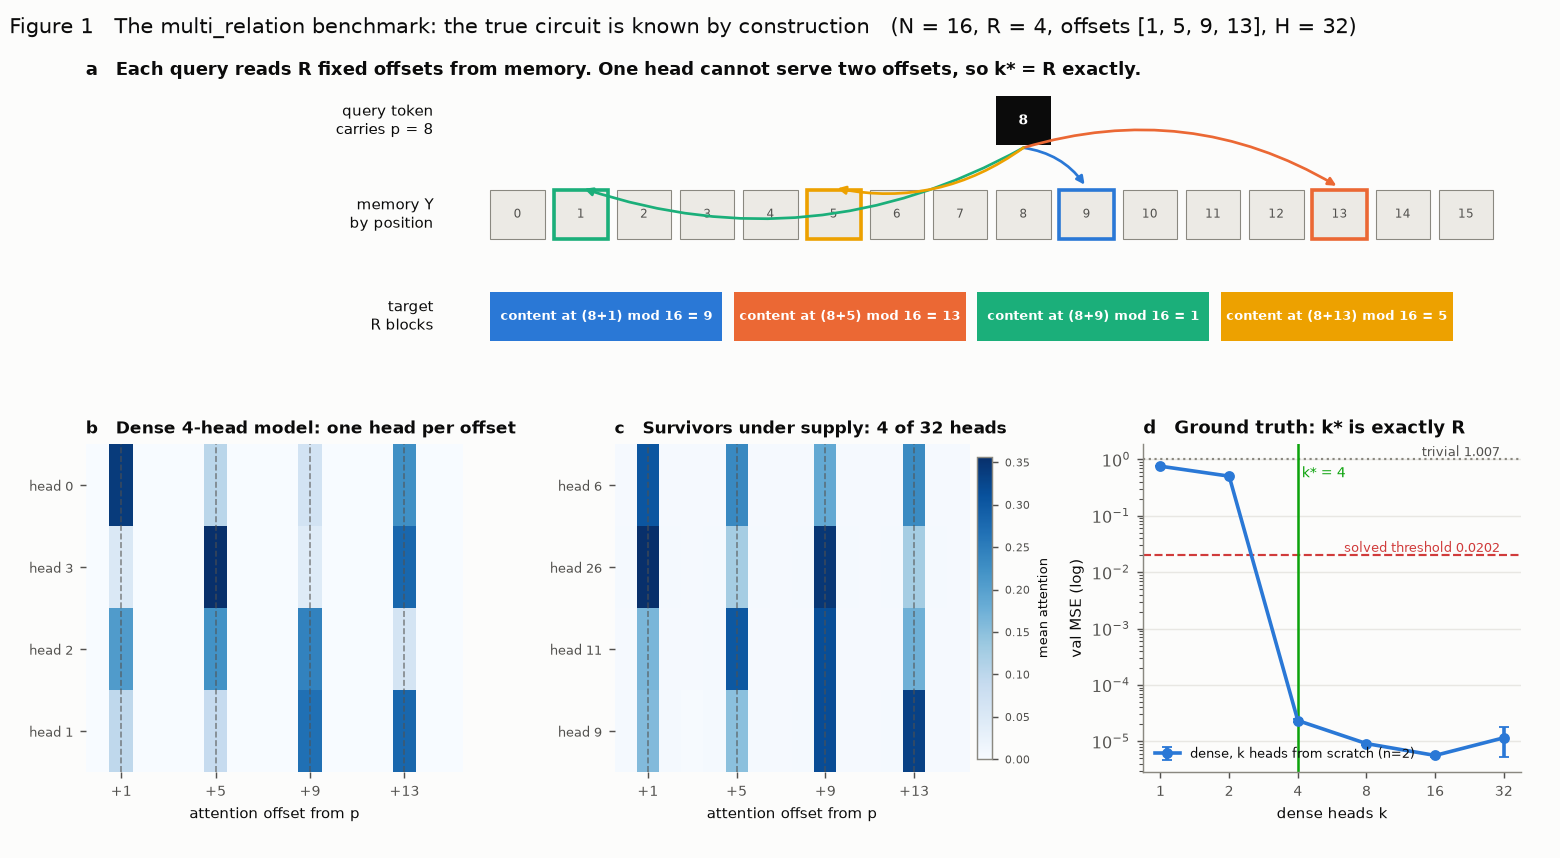

Figure 2: only the closed loop tracks k*


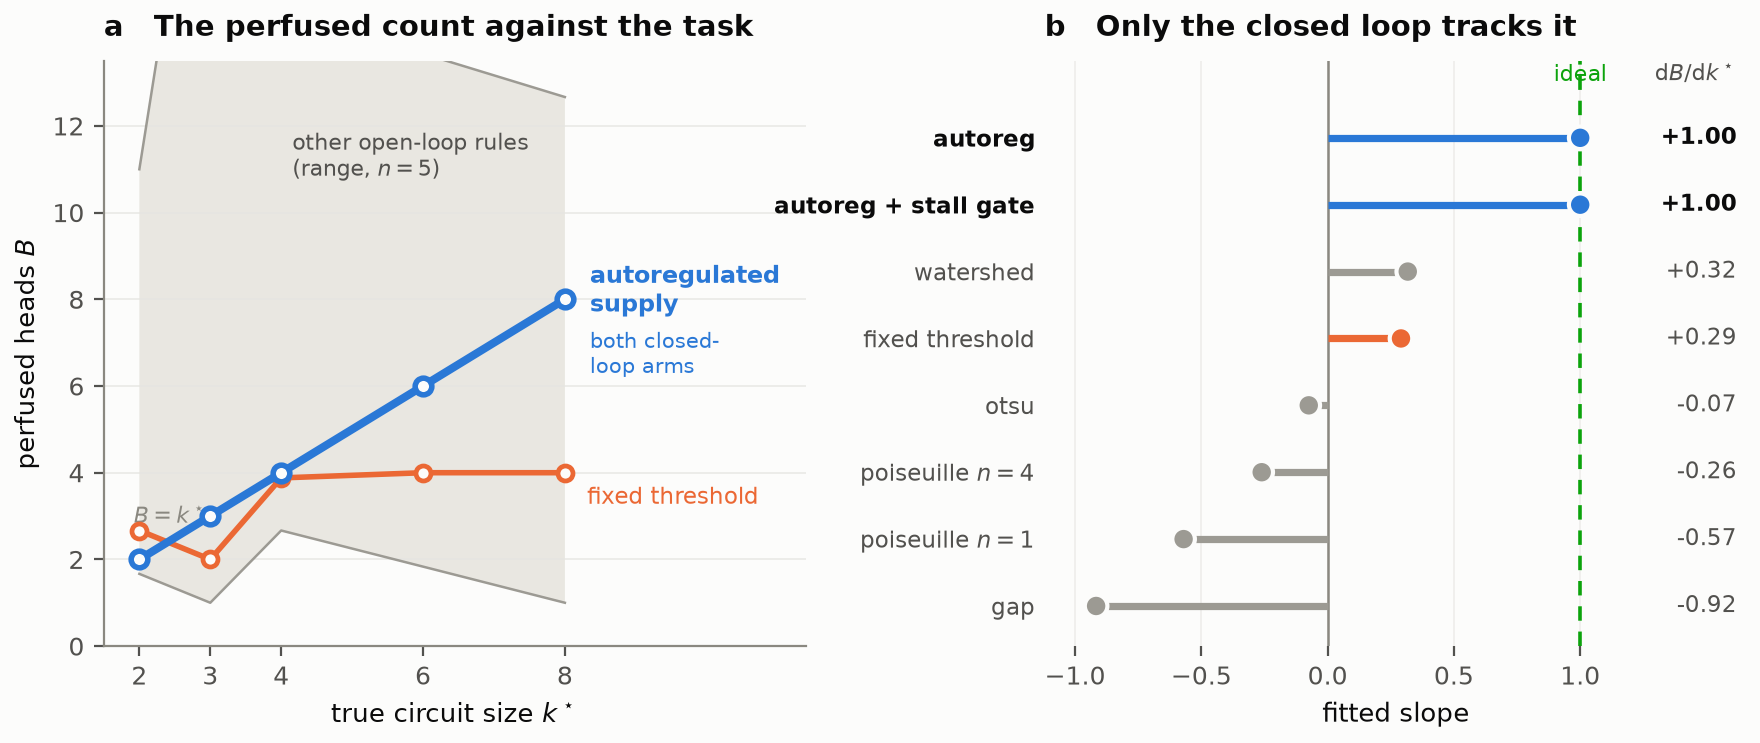

In [8]:
from IPython.display import Image, display
for f, cap in [("../figures/fig1_task.png", "Figure 1: the benchmark"),
               ("../figures/fig_arms.png", "Figure 2: only the closed loop tracks k*")]:
    print(cap); display(Image(filename=f))

## 8. Train one live, if you want to see it move

About 4 minutes on CPU. Watch `perfused` settle on `k*`.

In [9]:
# cfg = Cfg(device="cpu", supply="autoreg", stall_gate=0.02, n_rel=4, steps=4000)
# val = make_val(cfg, "cpu")
# model, hist = train(cfg, val, "cpu", hemo=True, desc="live", verbose=True)
# print("final perfused:", hist["final_perfused"], " k* =", predicted_kstar(cfg))

## 9. What is not shown here

Four mechanisms produced **null results** and are kept rather than dropped: territory
compaction, a delay line between demand and supply, pooled demand, and the finding that
the signal the mechanism gates on is *not* the best available predictor of causal head
importance. See `README.md` and `paper/chapter.tex`.

Three limitations bear on how the result should be stated, and they are in
`paper/chapter.tex` Section 7. The sharpest: *the smallest circuit meeting a performance
bar* is close to the **definition** of the minimal circuit, so this is an efficiency
result about circuit discovery rather than a demonstration that metabolic constraint
reveals circuit size from first principles.